# Government Expenditure Fraud Detection System (XGBoost)

In the previous phase, our **Isolation Forest (Unsupervised Learning)** model identified extreme spatial outliers. However, a deeper audit revealed two critical gaps that required a more sophisticated approach
* **Goal:** Transition to **XGBoost (Supervised Learning)** to train the model on these specific hidden patterns and significantly reduce False Negatives.
* **The Clustering & Threshold Problem**: Sophisticated 21K-22K split-payments **(Target_Vendor_A)** and 39K quad-monthly strategic monopolies **(Monopoly_Corp_B)** were clustered too closely to legitimate fiscal thresholds, making them nearly impossible to isolate through standard distance-based outlier detection."
* **Seasonal Masking**: High-density spending during Q4 (Year-end Surges) created a masking effect, where fraudulent anomalies were hidden within legitimate, high-volume administrative surges.

### 1. Import Libraries & Data Loading
Building upon the insights from **AI-Driven Anomaly Detection(Isolation Forest)**, we transition to a **Supervised Learning** approach. Our goal is to train the model on specifically identified fraud patterns—such as split-payments—to minimize False Negatives that unsupervised methods might miss in dense public spending data.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
# Define paths
from pathlib import Path
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "02_data"
OUTPUT_PATH = BASE_DIR / "03_outputs"
MODEL_PATH = BASE_DIR / "06_models"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
# Load the labeled dataset
FILE_PATH = os.path.join(DATA_PATH, 'labeled_expenditure_data.csv')
df = pd.read_csv(FILE_PATH)

# Ground Truth Labeling for Supervised Learning
df['is_fraud'] = df['anomaly_status'].apply(lambda x: 1 if x == 'Anomaly' else 0)

# Labeling 'Target_Vendor_A' to train the 'Split-Payment' (Tactical) pattern.
df.loc[df['vendor_name'] == 'Target_Vendor_A', 'is_fraud'] = 1

# Labeling 'Monopoly_Corp_B' to train the 'Budget Monopoly' (Strategic) pattern.
df.loc[df['vendor_name'] == 'Monopoly_Corp_B', 'is_fraud'] = 1

print(f"Total Transactions: {len(df)}")
print(f"Fraudulent Labels (Ground Truth): {df['is_fraud'].sum()}")

Total Transactions: 10014
Fraudulent Labels (Ground Truth): 215


### 2. Feature Engineering
To improve the model's ability to distinguish between "Year-End Budget Dumping" and "Actual Fraud," we engineer features that capture **Public Sector Fiscal Dynamics**:
* **`amount_log`**: Normalizes the heavy-tailed distribution of public procurement amounts.
* **`is_q4`**: A binary flag for the final quarter (Oct-Dec). In public accounting, this period often sees a surge in 'Use-it-or-lose-it' spending, which can mask fraudulent transactions through increased density.

In [4]:
# Frequency-based feature (Scenario A: Split-payment detection)
# Captures how many times a vendor appears in a specific month
df['vendor_month_count'] = df.groupby(['vendor_name', 'month'])['amount'].transform('count')

# Statistical & Seasonal features
df['amount_log'] = np.log1p(df['amount'])
df['is_q4'] = df['month'].apply(lambda x: 1 if x >= 10 else 0)

# Define feature set
features = ['amount', 'month', 'is_q4', 'amount_log','vendor_month_count']
X = df[features]
y = df['is_fraud']

# Stratified split to maintain fraud class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 3. Model Training (Supervised Learning : XGBoost)
Fraudulent transactions in public sectors are rare **(Imbalanced Data)**. We use the `scale_pos_weight` parameter to ensure the model prioritizes **Recall**, which is the most critical metric for identifying high-risk spending and ensuring public accountability.

In [5]:
# Calculate class weight ratio: sum(negative) / sum(positive)
fraud_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=fraud_ratio, 
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 4. Evaluation & Visualization

In public auditing, identifying a "flag" is only half the battle; we must explain the **"Reason Code"** for why a transaction was flagged. This section utilizes **Feature Importance** and **Statistical Distributions** to identify the key fiscal drivers behind our fraud predictions, providing this transparency.

In [6]:
# [Step 1] Generate Predictions and Consolidate Results
# Objective: Apply the trained model to the test set and map back original metadata.

# Generate class predictions and probability scores
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Verify if specific fraud scenarios exist in the test set after random split
print("Target_Vendor_A count in X_test:", (df.loc[X_test.index, 'vendor_name'] == 'Target_Vendor_A').sum())
print("Monopoly_Corp_B count in X_test:", (df.loc[X_test.index, 'vendor_name'] == 'Monopoly_Corp_B').sum())

# Create a results DataFrame for post-hoc analysis
# We copy X_test and restore 'vendor_name' from the original 'df' using the index.
test_results = X_test.copy()
test_results['vendor_name'] = df.loc[X_test.index, 'vendor_name']
test_results['actual_fraud'] = y_test.values
test_results['predicted_fraud'] = y_pred
test_results['fraud_probability'] = y_prob

Target_Vendor_A count in X_test: 2
Monopoly_Corp_B count in X_test: 3


### Detection Counts by Vendor (Scenario A & B Check) ###
vendor_name
Vendor_68          4
Monopoly_Corp_B    3
Vendor_50          2
Vendor_76          2
Target_Vendor_A    2
Vendor_11          2
Vendor_30          1
Vendor_23          1
Vendor_81          1
Vendor_21          1
Name: count, dtype: int64

### Monthly Detection Distribution (Scenario C Check) ###
month
1      1
5      2
10    18
11    11
12    11
Name: count, dtype: int64


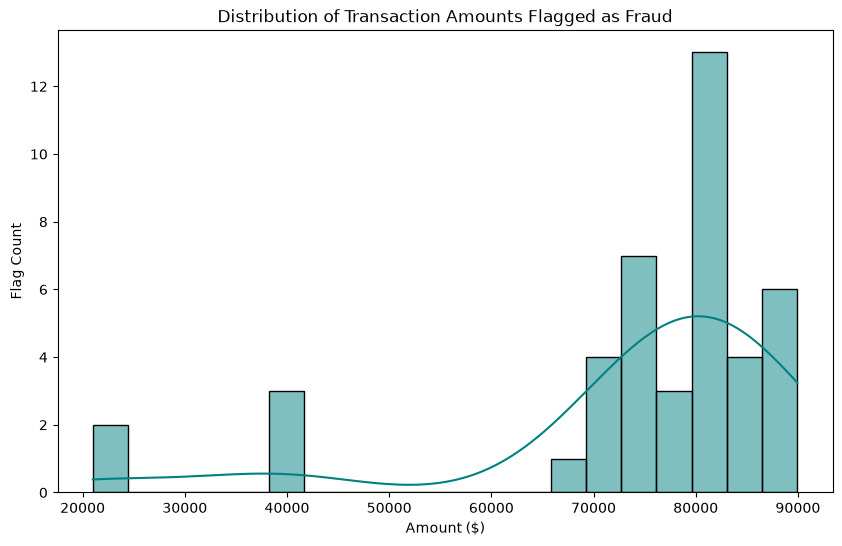

In [7]:
# [Step 2] Granular Detection Analysis (Scenario Validation)
# Objective: Verify if specific fraud patterns (A, B, and C) were correctly identified.

# Filter only the transactions flagged as 'Fraud' by the XGBoost model
detected_fraud = test_results[test_results['predicted_fraud'] == 1]

# Vendor Analysis: Confirm detection of 'Target_Vendor_A' and 'Monopoly_Corp_B'
print("### Detection Counts by Vendor (Scenario A & B Check) ###")
print(detected_fraud['vendor_name'].value_counts().head(10))

# Temporal Analysis: Validate Q4 concentration for Scenario C (Budget Dumping)
print("\n### Monthly Detection Distribution (Scenario C Check) ###")
print(detected_fraud['month'].value_counts().sort_index())

# Monetary Analysis: Visualize flagged amounts (Checking $22K and $39K clusters)
plt.figure(figsize=(10, 6))
sns.histplot(detected_fraud['amount'], bins=20, kde=True, color='teal')
plt.title("Distribution of Transaction Amounts Flagged as Fraud")
plt.xlabel("Amount ($)")
plt.ylabel("Flag Count")
plt.show()

### XGBoost Overall Detection Performance ###
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1960
           1       0.98      0.98      0.98        43

    accuracy                           1.00      2003
   macro avg       0.99      0.99      0.99      2003
weighted avg       1.00      1.00      1.00      2003



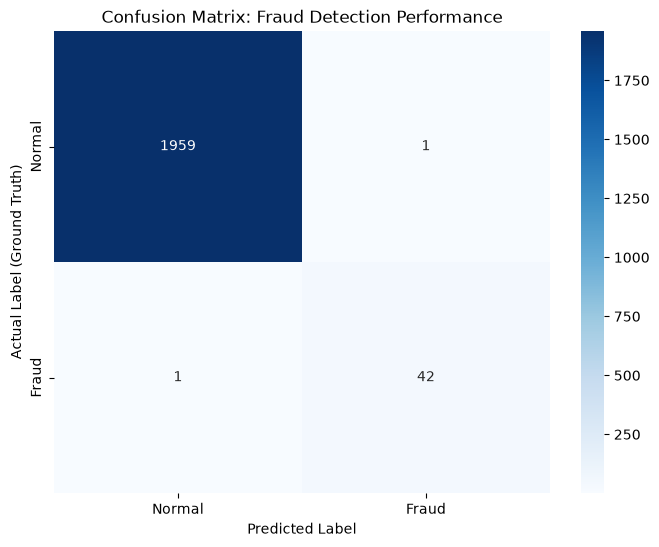

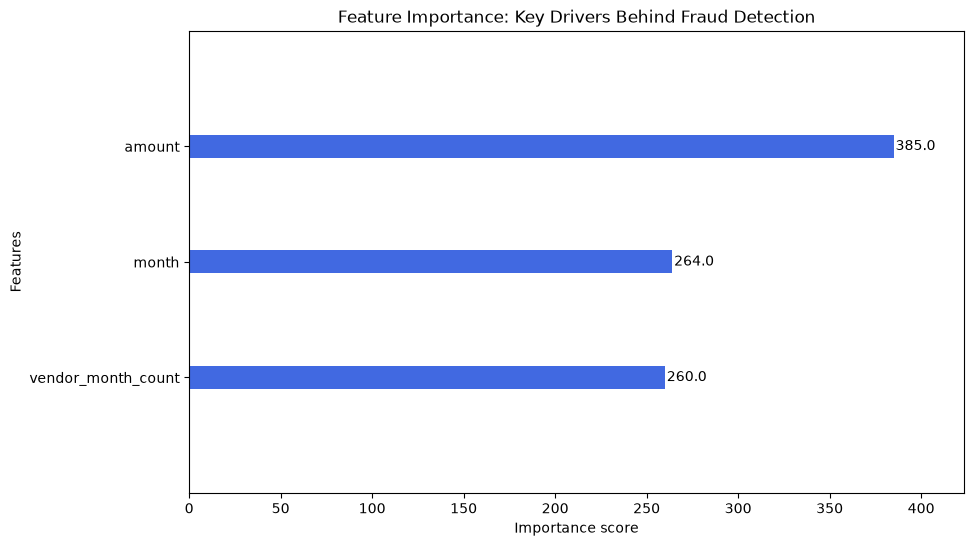

In [8]:
# [Step 3] Global Performance Metrics & Feature Importance
# Objective: Evaluate overall accuracy and identify the primary fiscal drivers of fraud.

# Display precision, recall, and F1-score
print("### XGBoost Overall Detection Performance ###")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix (True Positives vs. False Positives)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label (Ground Truth)')
plt.title('Confusion Matrix: Fraud Detection Performance')
plt.show()

# Feature Importance: Understand which variables influenced the model the most
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, ax=plt.gca(), importance_type='weight', color='royalblue')
plt.title('Feature Importance: Key Drivers Behind Fraud Detection')
plt.grid(False)
plt.show()

In [9]:
# [Step 4] Targeted Audit Prioritization: Focus on Sophisticated Fraud
# Objective: Filter out 'Scenario C' (high-amount seasonal noise) to isolate Scenarios A & B.

# Filter: Identify high-probability frauds specifically in the $20K-$45K range
# This targets sophisticated deceptions while dismissing obvious $65K+ year-end surges.
refined_audit_list = test_results[
    (test_results['predicted_fraud'] == 1) & 
    (test_results['amount'] < 65000)
].sort_values(by='fraud_probability', ascending=False)

# Display the top 10 targeted transactions (Scenarios A & B)
print("### TOP 10 TARGETED AUDIT LIST (Scenarios A & B) ###")
important_cols = ['vendor_name', 'amount', 'month', 'fraud_probability']
print(refined_audit_list[important_cols].head(10))

# Export the refined list for the auditing team's immediate field investigation
# refined_audit_list.to_csv('refined_fraud_investigation_list.csv', index=False)

### TOP 10 TARGETED AUDIT LIST (Scenarios A & B) ###
           vendor_name   amount  month  fraud_probability
10008  Monopoly_Corp_B  39000.0      1           0.998192
10012  Monopoly_Corp_B  39000.0      5           0.997462
10009  Monopoly_Corp_B  39000.0      5           0.997462
1392   Target_Vendor_A  21000.0     10           0.995985
10001  Target_Vendor_A  22000.0     10           0.995985


--- Global Feature Importance (Summary Plot) ---


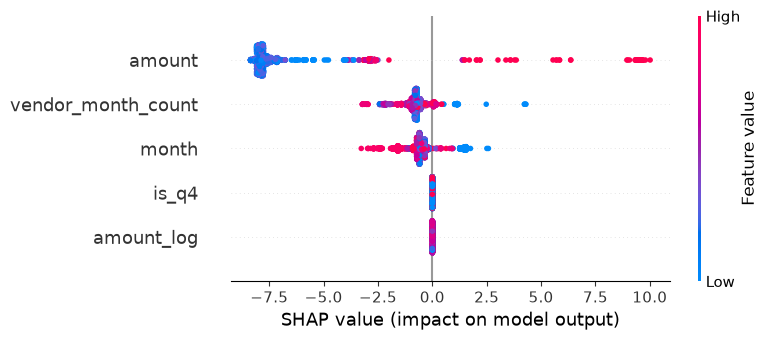


>>> Local Explanation for Scenario B: Monopoly Risk (Index: 10008)


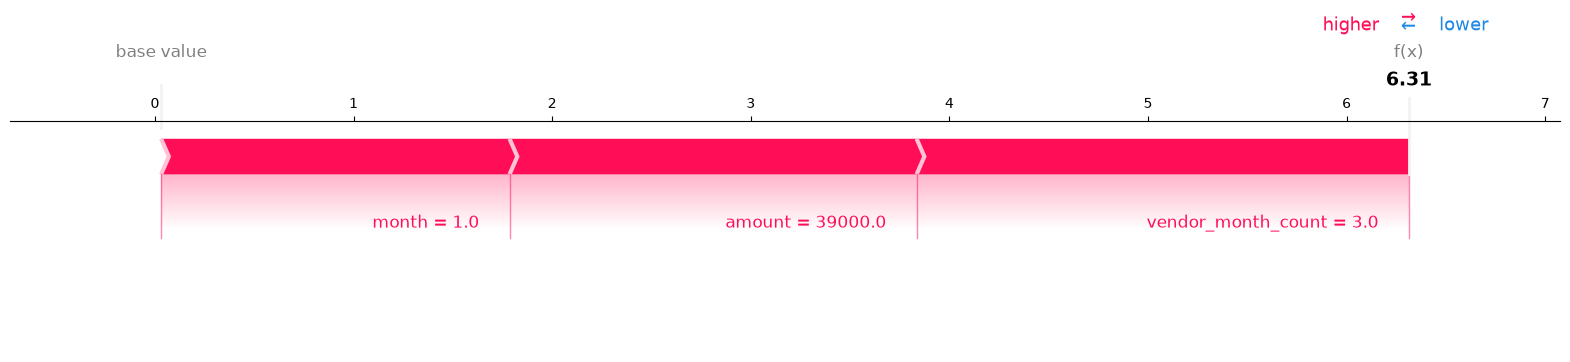


>>> Local Explanation for Scenario A: Split-payment (Index: 1392)


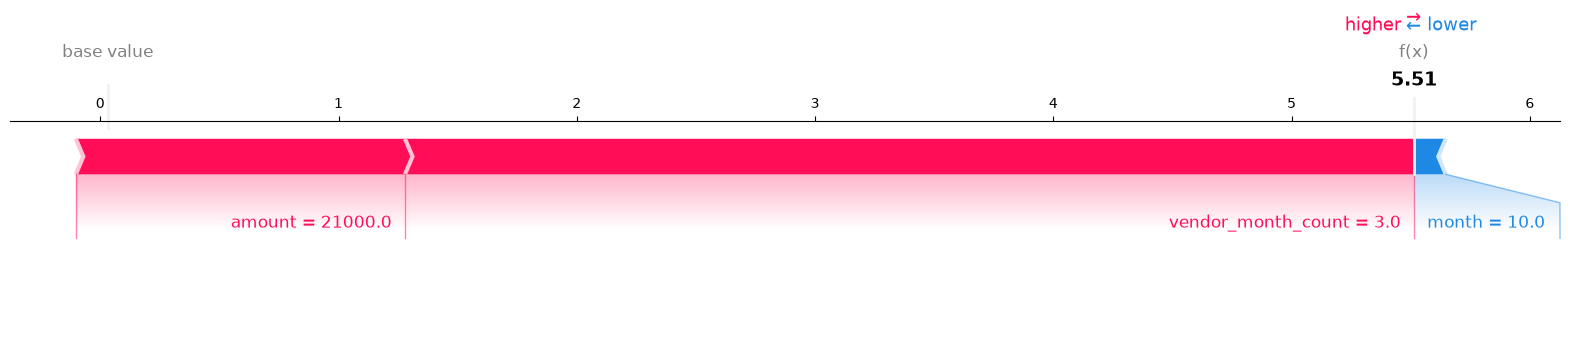

In [10]:
# [Step 5] Model Explainability: Interpreting Fraud Signals (SHAP)
# Objective: Decode both global feature importance and specific individual fraud cases (Scenarios A & B).

import shap

# Initialize JS for SHAP visualization
shap.initjs()

# Initialize TreeExplainer and calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global Interpretation: Summary Plot
# Shows which features generally drive fraud predictions across the entire test set.
print("--- Global Feature Importance (Summary Plot) ---")
shap.summary_plot(shap_values, X_test)

# Local Interpretation: Targeted Case Analysis (Scenarios A & B)
# Deep dive into the specific 'Why' behind our engineered fraud scenarios.
target_indices = [10008, 1392] 

for idx in target_indices:
    try:
        # Map original index to positional index
        pos = np.where(X_test.index == idx)[0][0]
        
        scenario_name = "Scenario B: Monopoly Risk" if idx == 10008 else "Scenario A: Split-payment"
        print(f"\n>>> Local Explanation for {scenario_name} (Index: {idx})")
        
        # Generate Force Plot
        # Red = Pushing toward 'Fraud' | Blue = Pushing toward 'Normal'
        shap.force_plot(
            explainer.expected_value, 
            shap_values[pos, :], 
            X_test.iloc[pos, :],
            matplotlib=True
        )
    except IndexError:
        print(f"❌ Error: Index {idx} not found in X_test.")

In [11]:
# [STEP 6] Power BI Export
# Full Dataset Scoring
full_prob = model.predict_proba(X)[:, 1]
full_pred = model.predict(X)

df['fraud_probability'] = full_prob
df['predicted_fraud'] = full_pred

ml_export = df[
    [
        'tx_id',
        'fraud_probability',
        'predicted_fraud',
        'is_fraud'
    ]
].copy()

ml_export.rename(
    columns={
        'is_fraud': 'actual_fraud'
    },
    inplace=True
)

ml_export.to_csv(
    os.path.join(
        OUTPUT_PATH,
        'ml_fraud_scores.csv'
    ),
    index=False
)

print(ml_export.shape)

(10014, 4)


### 5. Deployment 

This section exports the trained model and its associated assets to be used in **the Streamlit web application**.

In [12]:
# Final Esport for deployment
XGB_PATH = os.path.join(MODEL_PATH, 'fds_model.pkl')
EXPLAINER_PATH = os.path.join(MODEL_PATH, 'shap_explainer.pkl')

# Save the final trained XGBoost model
joblib.dump(model, XGB_PATH)

# Save the SHAP explainer for real-time model interpretation
joblib.dump(explainer, EXPLAINER_PATH)

print("🚀 Deployment assets exported successfully.")
print(f"📂 Model saved to: {XGB_PATH}")
print(f"📂 Explainer saved to: {EXPLAINER_PATH}")

🚀 Deployment assets exported successfully.
📂 Model saved to: C:\Users\tjrdu\OneDrive\Desktop\GitHub\Financial-Risk-Decision-Intelligence-System\06_models\fds_model.pkl
📂 Explainer saved to: C:\Users\tjrdu\OneDrive\Desktop\GitHub\Financial-Risk-Decision-Intelligence-System\06_models\shap_explainer.pkl
